In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)

df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Fixing TotalCharges

# Convert to numeric, forcing errors to NaN so we can find the bad rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Missing Total Charges: {df['TotalCharges'].isnull().sum()}")

# Display rows with missing TotalCharges
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Missing Total Charges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
# Handling Those missing Rows

# These are almost certainly tenure=0 customers, then we have to fill it 0 (they haven't been charged yet)

print(df[df['TotalCharges'].isnull()]['tenure'].unique())

df['TotalCharges'] = df['TotalCharges'].fillna(0)

[0]


In [7]:
# Dropping customerID as it is not a feature

df.drop('customerID', axis = 1, inplace = True)

df.shape

(7043, 20)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


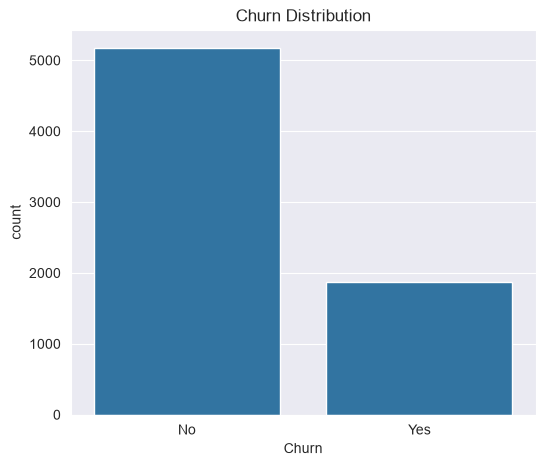

In [8]:
# Target vairable balance

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize = True)* 100)

plt.figure(figsize = (6,5))
sns.countplot(data = df, x = 'Churn')

plt.title('Churn Distribution')
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

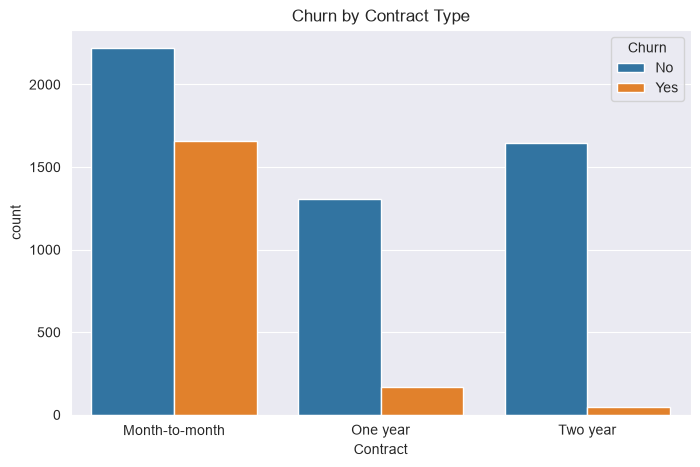

In [9]:
# Churn by contract type

plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'Contract', hue = 'Churn')

plt.title('Churn by Contract Type')
plt.savefig('churn_by_contract.png', dpi = 150)
plt.show()

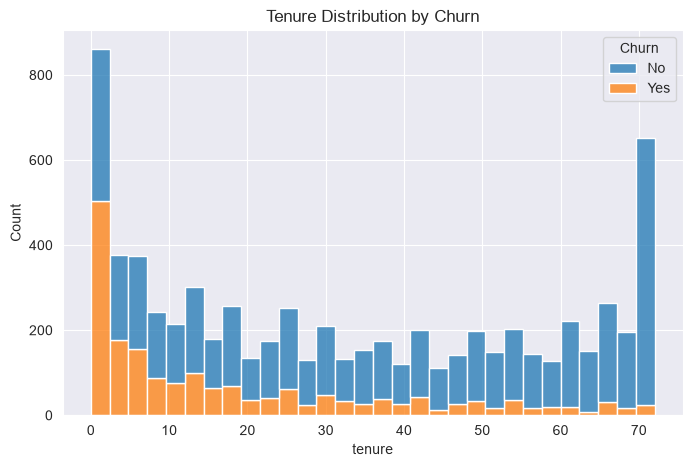

In [10]:
# Churn by Tenure

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')

plt.title('Tenure Distribution by Churn')
plt.savefig('tenure_by_churn.png', dpi=150)
plt.show()

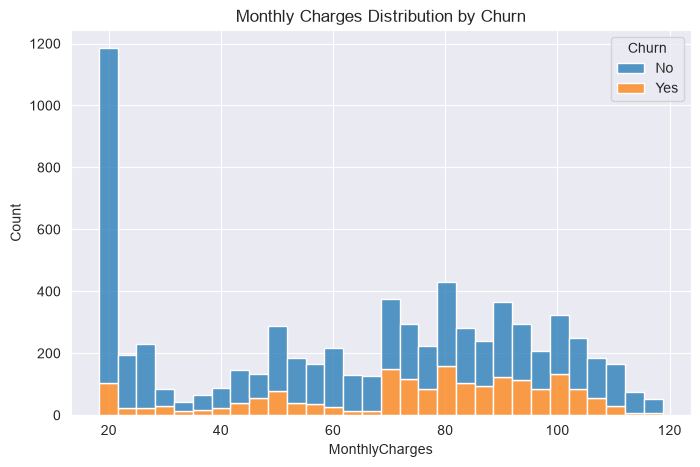

In [11]:
# Churn by Monthly Charges

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, multiple='stack')

plt.title('Monthly Charges Distribution by Churn')
plt.savefig('monthlycharges_by_churn.png', dpi=150)
plt.show()

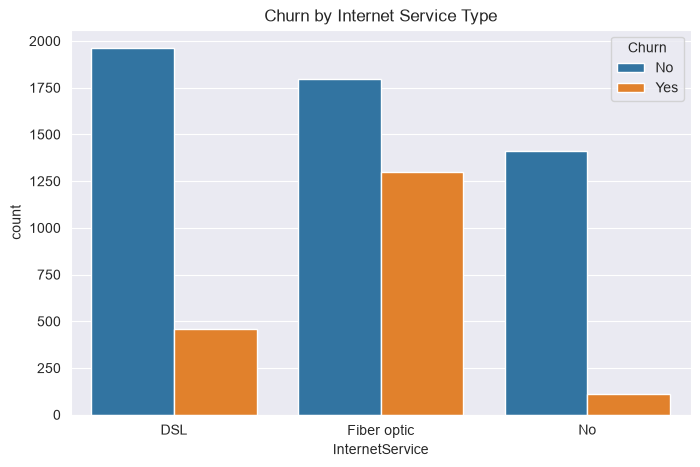

In [12]:
# Churn by Internet Service Type

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Churn by Internet Service Type')
plt.savefig('churn_by_internet.png', dpi=150)
plt.show()

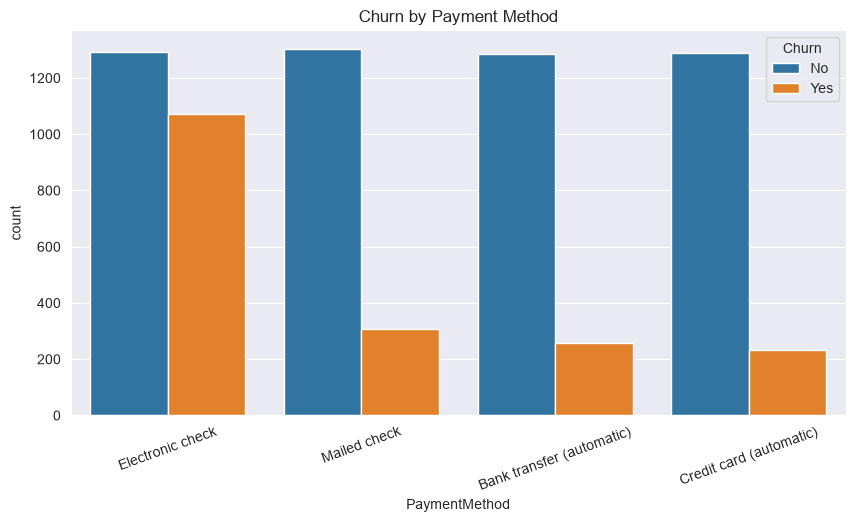

In [13]:
# Churn by Payment Method

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=20)

plt.title('Churn by Payment Method')
plt.savefig('churn_by_payment.png', dpi=150)
plt.show()

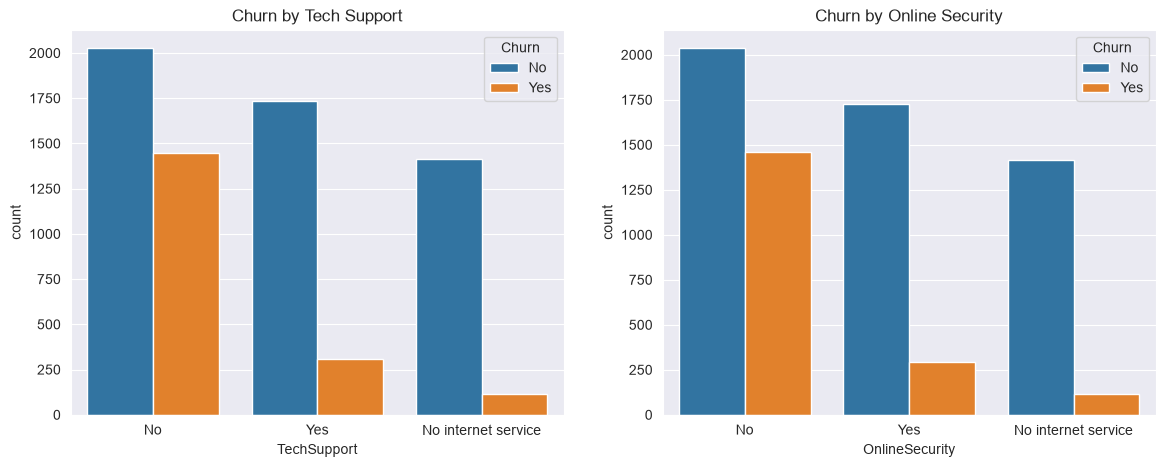

In [14]:
# Churn by Tech Support / Online Security

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by Tech Support')

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[1])
axes[1].set_title('Churn by Online Security')

plt.savefig('churn_by_support_services.png', dpi=150)
plt.show()

In [15]:
print("Churn rate by TechSupport:")
print(df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100)

print("\nChurn rate by OnlineSecurity:")
print(df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack() * 100)

Churn rate by TechSupport:
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341

Churn rate by OnlineSecurity:
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [16]:
# Separate feature types

# Binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Multi-category columns nedding one-hot encoding
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                     'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                     'StreamingMovies', 'Contract', 'PaymentMethod']

# Numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

print(f"Binary: {len(binary_cols)}")
print(f"Categorical: {len(categorical_cols)}")
print(f"Numeric: {len(numeric_cols)}")

Binary: 5
Categorical: 11
Numeric: 4


In [17]:
# Encoding Yes/No to 1/0

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

df[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [18]:
# One-hot encode multi-category columns

df_encoded = pd.get_dummies(df, columns = categorical_cols, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [19]:
# Train/test split 

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(5634, 30) (1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [20]:
# Scaling numeric Feature for Logistic Regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17,7.440898e-17
std,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00,-4.417730e-01
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01,-4.417730e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01,-4.417730e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01,-4.417730e-01
max,1.608483e+00,1.785939e+00,2.801869e+00,2.263606e+00


In [21]:
# Import Logistic Regression model and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Logistic Regression model
# max_iter=1000 increases the maximum iterations to ensure convergence
# class_weight='balanced' handles class imbalance by assigning higher weight to the minority class
# pay more attention ot the minority class.
# random_state=42 ensures reproducible results
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model on the training data
log_reg.fit(X_train, y_train)

# Make predictions on the test data
log_preds = log_reg.predict(X_test)

# Print the overall accuracy of the model
print(f'Accuracy: {accuracy_score(y_test, log_preds)}')

# Print precision, recall, F1-score, and support for each class
print(classification_report(y_test, log_preds))

Accuracy: 0.7388218594748048
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [22]:
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# n_estimators=200 -> Uses 200 decision trees
# max_depth=8 -> Limits each tree to a maximum depth of 8 to reduce overfitting
# class_weight='balanced' -> Assigns higher weight to the minority class to handle class imbalance
# random_state=42 -> Ensures reproducible results
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

# Train the model on the training data
rf.fit(X_train, y_train)

# Predict the target values for the test dataset
rf_preds = rf.predict(X_test)

# Print the overall accuracy of the model
print(f'Accuracy: {accuracy_score(y_test, rf_preds)}')

# Print precision, recall, F1-score, and support for each class
print(classification_report(y_test, rf_preds))

Accuracy: 0.752306600425834
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [23]:
!pip install imbalanced-learn

In [24]:
# Import SMOTE for handling class imbalance
# SMOTE (Synthetic Minority Over-sampling Technique) is a technique used 
# to balance an imbalanced dataset by creating new synthetic samples 
# for the minority class instead of simply duplicating existing ones.
    
from imblearn.over_sampling import SMOTE

# Create the SMOTE object
# random_state=42 ensures reproducible synthetic sample generation
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
# Generates synthetic samples for the minority class to balance the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display the class distribution before applying SMOTE
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')

# Display the class distribution after applying SMOTE
print(f'After SMOTE: {y_train_smote.value_counts().to_dict()}')

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [25]:
# Logistic Regression on SMOTE data

log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)

log_reg_smote.fit(X_train_smote, y_train_smote)

log_smote_preds = log_reg_smote.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, log_smote_preds)}')
print(classification_report(y_test, log_smote_preds))

Accuracy: 0.7374024130589071
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1035
           1       0.50      0.70      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



In [26]:
# Random Forest on SMOTE data

rf_smote = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_preds = rf_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_smote_preds))
print(classification_report(y_test, rf_smote_preds))

Accuracy: 0.752306600425834
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [27]:
# The Best Among all 4 is Random Forest ith balanced class wieght

# GridSearchCV on Random Forest

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = param_grid,
    cv=5,
    scoring='recall', # optimizing for recall on churners, not accuracy — matches our actual goal
    n_jobs= -1,
    verbose = 1 # Prints basic progress messages.
)

grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV recall: {grid_search.best_score_}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV recall: 0.8133779264214047


In [28]:
# Evaluate the tuned model on test set

best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, best_preds))

print(classification_report(y_test, best_preds))

Tuned RF Accuracy: 0.7416607523066004
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409



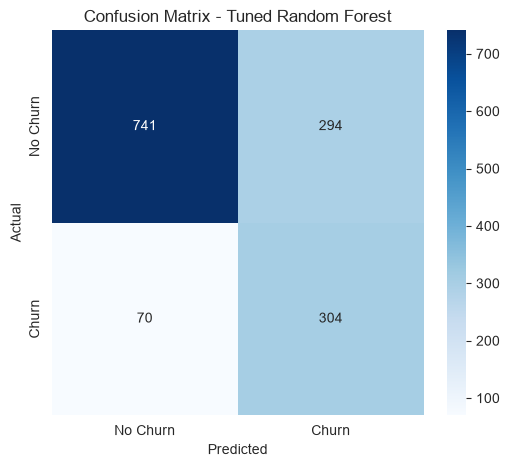

In [30]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize = (6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

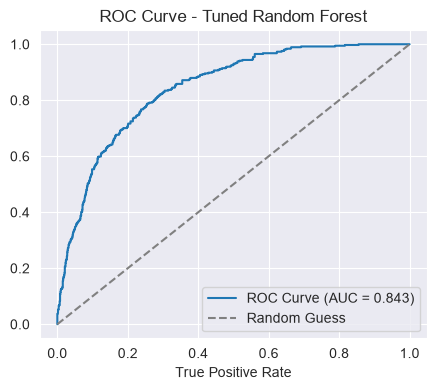

AUC Score: 0.8425


In [32]:
# ROC curve + AUC

from sklearn.metrics import roc_curve, roc_auc_score

y_probs = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize = (5,4))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], linestyle = '--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')

plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc:.4f}')

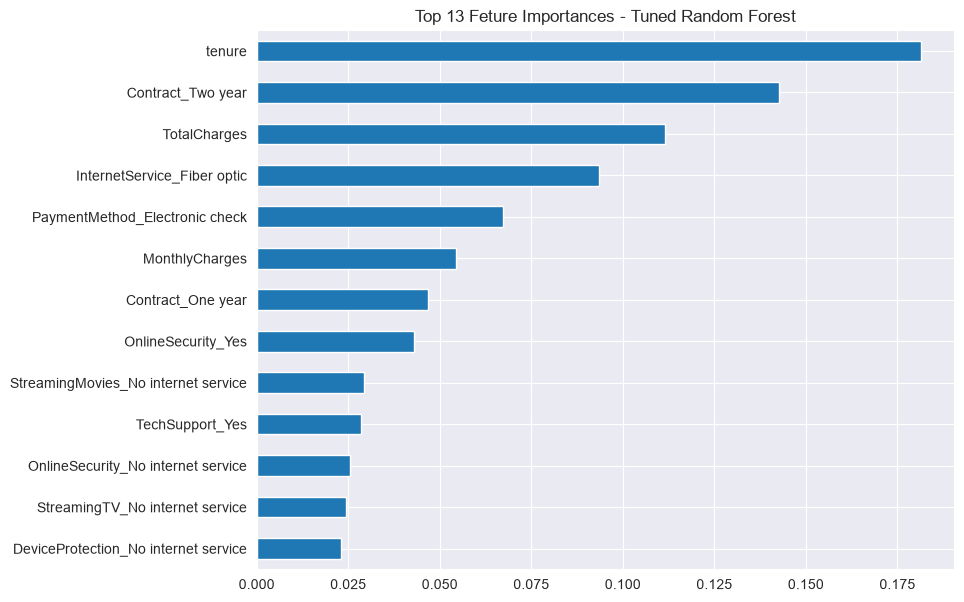

tenure                                  0.181434
Contract_Two year                       0.142518
TotalCharges                            0.111535
InternetService_Fiber optic             0.093542
PaymentMethod_Electronic check          0.067251
MonthlyCharges                          0.054360
Contract_One year                       0.046846
OnlineSecurity_Yes                      0.042877
StreamingMovies_No internet service     0.029204
TechSupport_Yes                         0.028613
OnlineSecurity_No internet service      0.025532
StreamingTV_No internet service         0.024439
DeviceProtection_No internet service    0.022965
dtype: float64


In [34]:
# Feature importance

importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(13)

plt.figure(figsize=(9,7))

importances.plot(kind='barh')
plt.title('Top 13 Feture Importances - Tuned Random Forest')

plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importances)

In [37]:
# Saving the model

import joblib

joblib.dump(best_rf, 'churn_predictor.pkl')
joblib.dump(best_rf, 'churn_scaler.pkl')

joblib.dump(X.columns.tolist(), 'churn_feature_columns.pkl')

['churn_feature_columns.pkl']

## Capstone Summary — Customer Churn Prediction

**Goal:** Predict which customers are likely to churn using account, service, and billing data, to support proactive retention efforts.

**Pipeline:** Data cleaning (fixed `TotalCharges` type issue, handled 11 tenure-0 edge cases) → EDA (6 key behavioral patterns identified) → feature encoding (binary + one-hot) → correctly ordered train/test split before any resampling → imbalance handling comparison → GridSearchCV tuning optimized for recall → final evaluation.

**Key EDA findings:** Two-year contracts retain best; churn concentrates heavily in low-tenure customers; fiber optic and electronic-check users churn more; lack of TechSupport/OnlineSecurity roughly triples churn rate (42% vs 15%).

**Imbalance handling:** Compared `class_weight='balanced'` against SMOTE across Logistic Regression and Random Forest. `class_weight='balanced'` outperformed SMOTE on recall in both cases — a reminder that synthetic oversampling isn't automatically superior, especially with heavily one-hot encoded data.

**Final model:** Random Forest (`max_depth=6, n_estimators=300`), tuned via GridSearchCV optimizing for recall rather than accuracy, since catching actual churners matters more than raw accuracy on this imbalanced target.

**Results:** 74.2% accuracy, 0.81 recall on churners, 0.8425 AUC.

**Why recall over accuracy:** A model that predicts "No Churn" for everyone would score ~73% accuracy while catching zero actual churners — useless for a retention use case. Optimizing for recall ensures the model actually identifies at-risk customers, even at some cost to precision (more false positives, which in a real business context is a cheaper mistake than missing a real churner).

**Model-EDA consistency:** The top model features (tenure, contract type, fiber optic, electronic check, charges) directly matched the patterns found during EDA — validating that the model learned genuine signal rather than noise.